# SVD e PCA per l'Analisi di Immagini Mediche

**Progetto — Statistical Methods**

Questo notebook dimostra come le tecniche di **Singular Value Decomposition (SVD)** e
**Principal Component Analysis (PCA)** possano essere utilizzate per comprimere e analizzare
radiografie polmonari in scala di grigi.

**Dataset:** Lung X-Rays Grayscale — 4 classi:
- Corona Virus Disease
- Normal
- Pneumonia
- Tuberculosis

In [8]:
# === IMPORT DEI MODULI DEL PROGETTO ===
from src.config import setup_plot_style
from src.data_loader import (count_images, print_image_counts,
                         load_sample_images, print_sample_properties,
                         load_dataset, load_raw_samples)
from src.svd_engine import apply_svd, print_svd_info
from src.visualization import (plot_exploration, plot_svd_reconstruction,
                           plot_class_comparison, plot_tilt_correction)
from src.analysis import (plot_scree, plot_mse_psnr,print_summary_table)
from src.pca_engine import (run_pca, plot_pca_scatter, plot_eigenfaces)

from src.classification import (prepare_feature_sets, run_classification,
                                plot_confusion_matrix, plot_roc_curves,
                                plot_classification_comparison,
                                plot_hero_tradeoff,
                                plot_knn_vs_lr)

setup_plot_style()

---
## Fase 1 -- Esplorazione dei Dati
Carichiamo le immagini, verifichiamo che siano matrici 2D in scala di grigi e ne studiamo le
caratteristiche statistiche di base.

In [9]:
# === CONTEGGIO IMMAGINI PER CLASSE ===
counts = count_images()
print_image_counts(counts)

CONTEGGIO IMMAGINI NEL DATASET

--- DATASET ---
  Corona Virus Disease          :  122 immagini
  Normal                        :  540 immagini
  Pneumonia                     :  186 immagini
  Tuberculosis                  :  333 immagini


In [10]:
# === CARICAMENTO E VERIFICA CAMPIONI ===
sample_images = load_sample_images()
print_sample_properties(sample_images)


PROPRIETA' DELLE IMMAGINI CAMPIONE

  Classe: Corona Virus Disease
    Shape:  (230, 203)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  116.07
    Std:    44.54
    2D?     Si [OK]

  Classe: Normal
    Shape:  (1654, 1678)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  124.91
    Std:    57.82
    2D?     Si [OK]

  Classe: Pneumonia
    Shape:  (1216, 1512)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    255
    Media:  77.16
    Std:    41.98
    2D?     Si [OK]

  Classe: Tuberculosis
    Shape:  (512, 512)  (altezza x larghezza)
    Dtype:  uint8
    Min:    0
    Max:    193
    Media:  126.62
    Std:    39.60
    2D?     Si [OK]


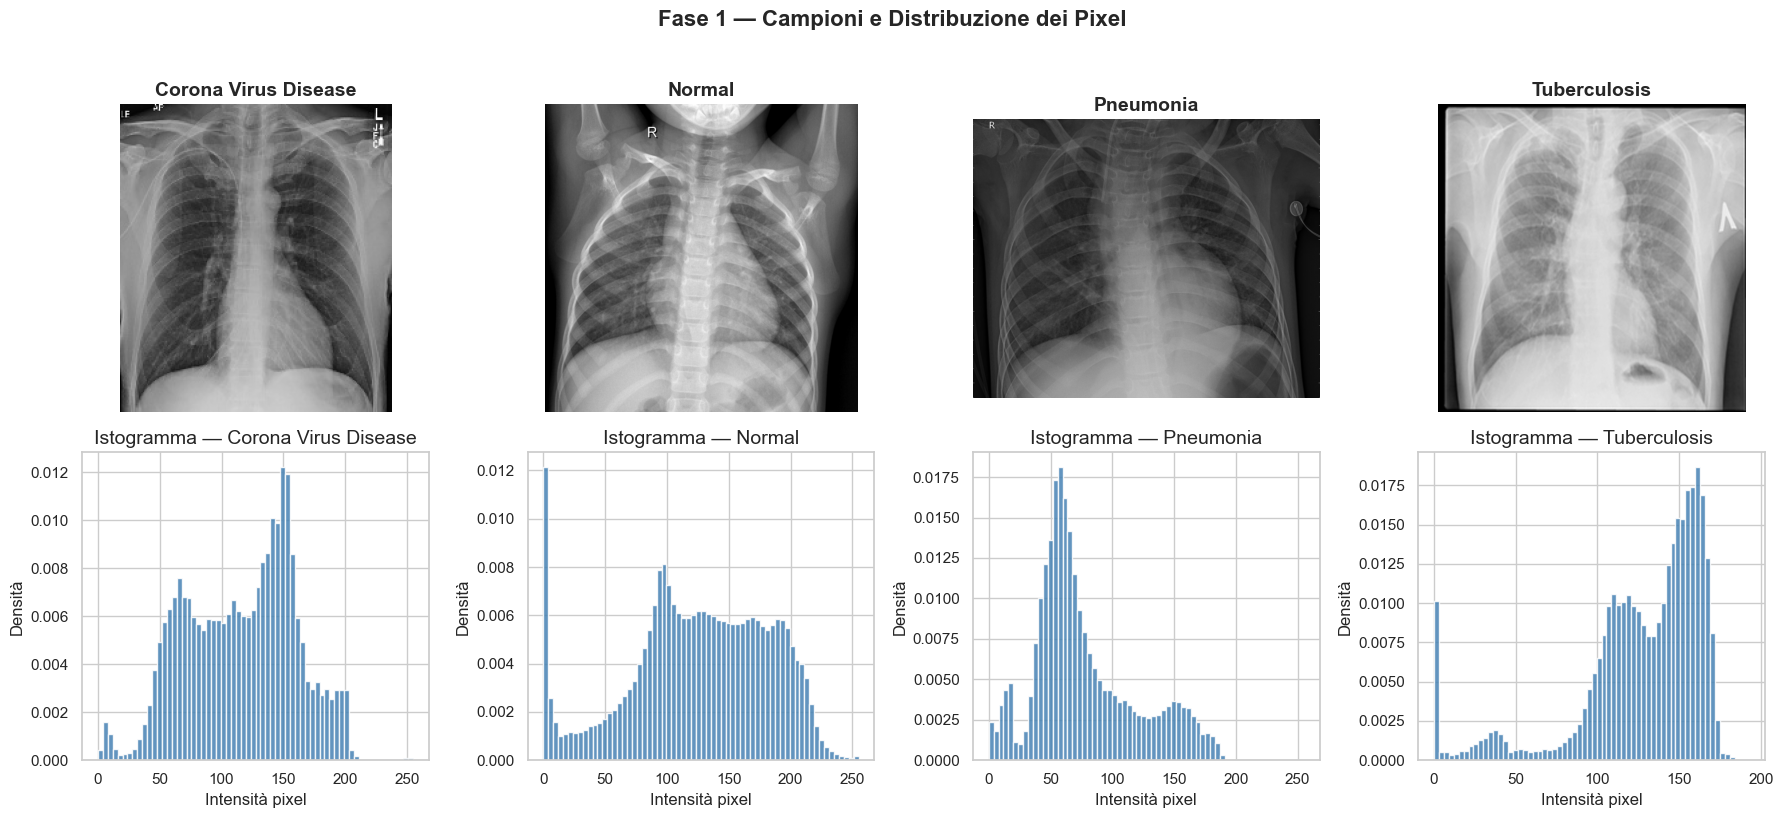

In [11]:
# === VISUALIZZAZIONE CAMPIONI + ISTOGRAMMA DEI PIXEL ===
plot_exploration(sample_images)

---
## Fase 2 -- Pre-elaborazione
Ridimensioniamo tutte le immagini a 256x256, le normalizziamo in [0, 1] e correggiamo
l'eventuale inclinazione (tilt) delle radiografie.

In [12]:
# === CARICAMENTO BATCH PRE-ELABORATO ===
images_by_class, all_images, labels = load_dataset()

  Caricate 116 immagini per 'Corona Virus Disease'  (scartate 6 con tilt > 10°)
  Caricate 120 immagini per 'Normal'  (scartate 1 con tilt > 10°)
  Caricate 120 immagini per 'Pneumonia'  (scartate 1 con tilt > 10°)
  Caricate 120 immagini per 'Tuberculosis'  (scartate 14 con tilt > 10°)

Dataset totale: (476, 256, 256)  --  476 immagini, 256x256 pixel


In [13]:
# === CORREZIONE TILT: PRIMA vs DOPO ===
raw_samples = load_raw_samples()
plot_tilt_correction(raw_samples)

---
## Fase 3 -- Il Motore Matematico: SVD

La **Singular Value Decomposition** scompone una matrice $A_{m \times n}$ come:

$$A = U \cdot \Sigma \cdot V^T$$

dove:
- $U$ (m x m): vettori singolari sinistri (strutture delle righe)
- $\Sigma$ (diagonale): valori singolari ordinati $\sigma_1 \geq \sigma_2 \geq \dots \geq 0$
- $V^T$ (n x n): vettori singolari destri (strutture delle colonne)

**Approssimazione di rango k:**

$$A_k = \sum_{i=1}^{k} \sigma_i \, \mathbf{u}_i \, \mathbf{v}_i^T$$

Usando solo le prime $k$ componenti si ottiene la migliore approssimazione di rango $k$
(teorema di Eckart-Young).

In [14]:
# === DEMO SVD SU UNA SINGOLA IMMAGINE ===
demo_img = images_by_class["Normal"][0]
U, S, Vt = apply_svd(demo_img)
print_svd_info(demo_img, U, S, Vt)

Immagine originale:  256 × 256 = 65,536 valori
Valori singolari:    256 = min(m, n)

Matrice U:   (256, 256)
Vettore S:   (256,)
Matrice Vt:  (256, 256)

Primi 10 valori singolari: [133.23  20.15  16.65  12.27  10.28   7.72   6.12   5.18   4.49   4.39]
Ultimi 5 valori singolari: [0.000904 0.000482 0.000251 0.000165 0.      ]


---
## Fase 4 -- Ricostruzione e Visualizzazione
Ricostruiamo l'immagine con diversi valori di $k$ e confrontiamo visivamente la qualita'.

    k    Compressione         MSE   PSNR (dB)
------------------------------------------------
    1          0.78%    0.018516       17.32
    5          3.91%    0.004147       23.82
   10          7.83%    0.001666       27.78
   20         15.66%    0.000579       32.37
   50         39.14%    0.000098       40.09
  100         78.28%    0.000010       50.00
  200        100.00%    0.000000       71.54


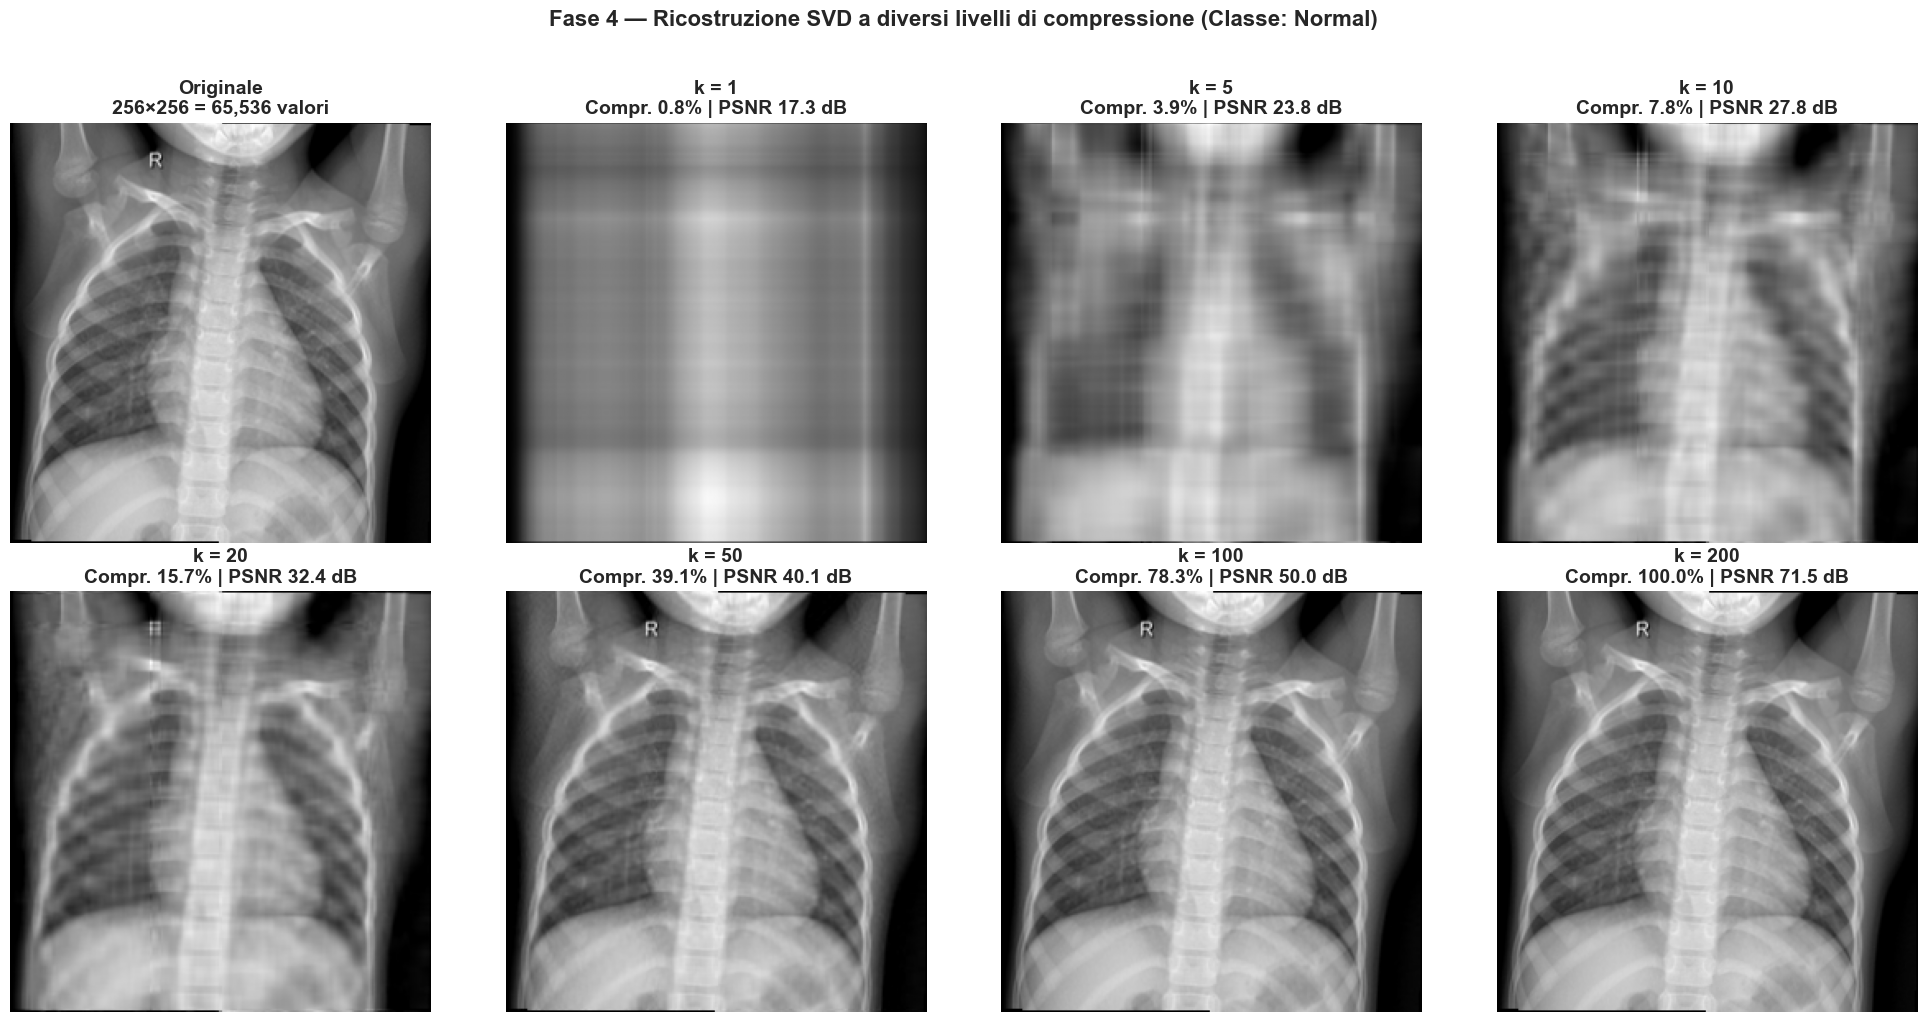

In [15]:
# === RICOSTRUZIONE CON DIVERSI k ===
plot_svd_reconstruction(demo_img, class_name="Normal")

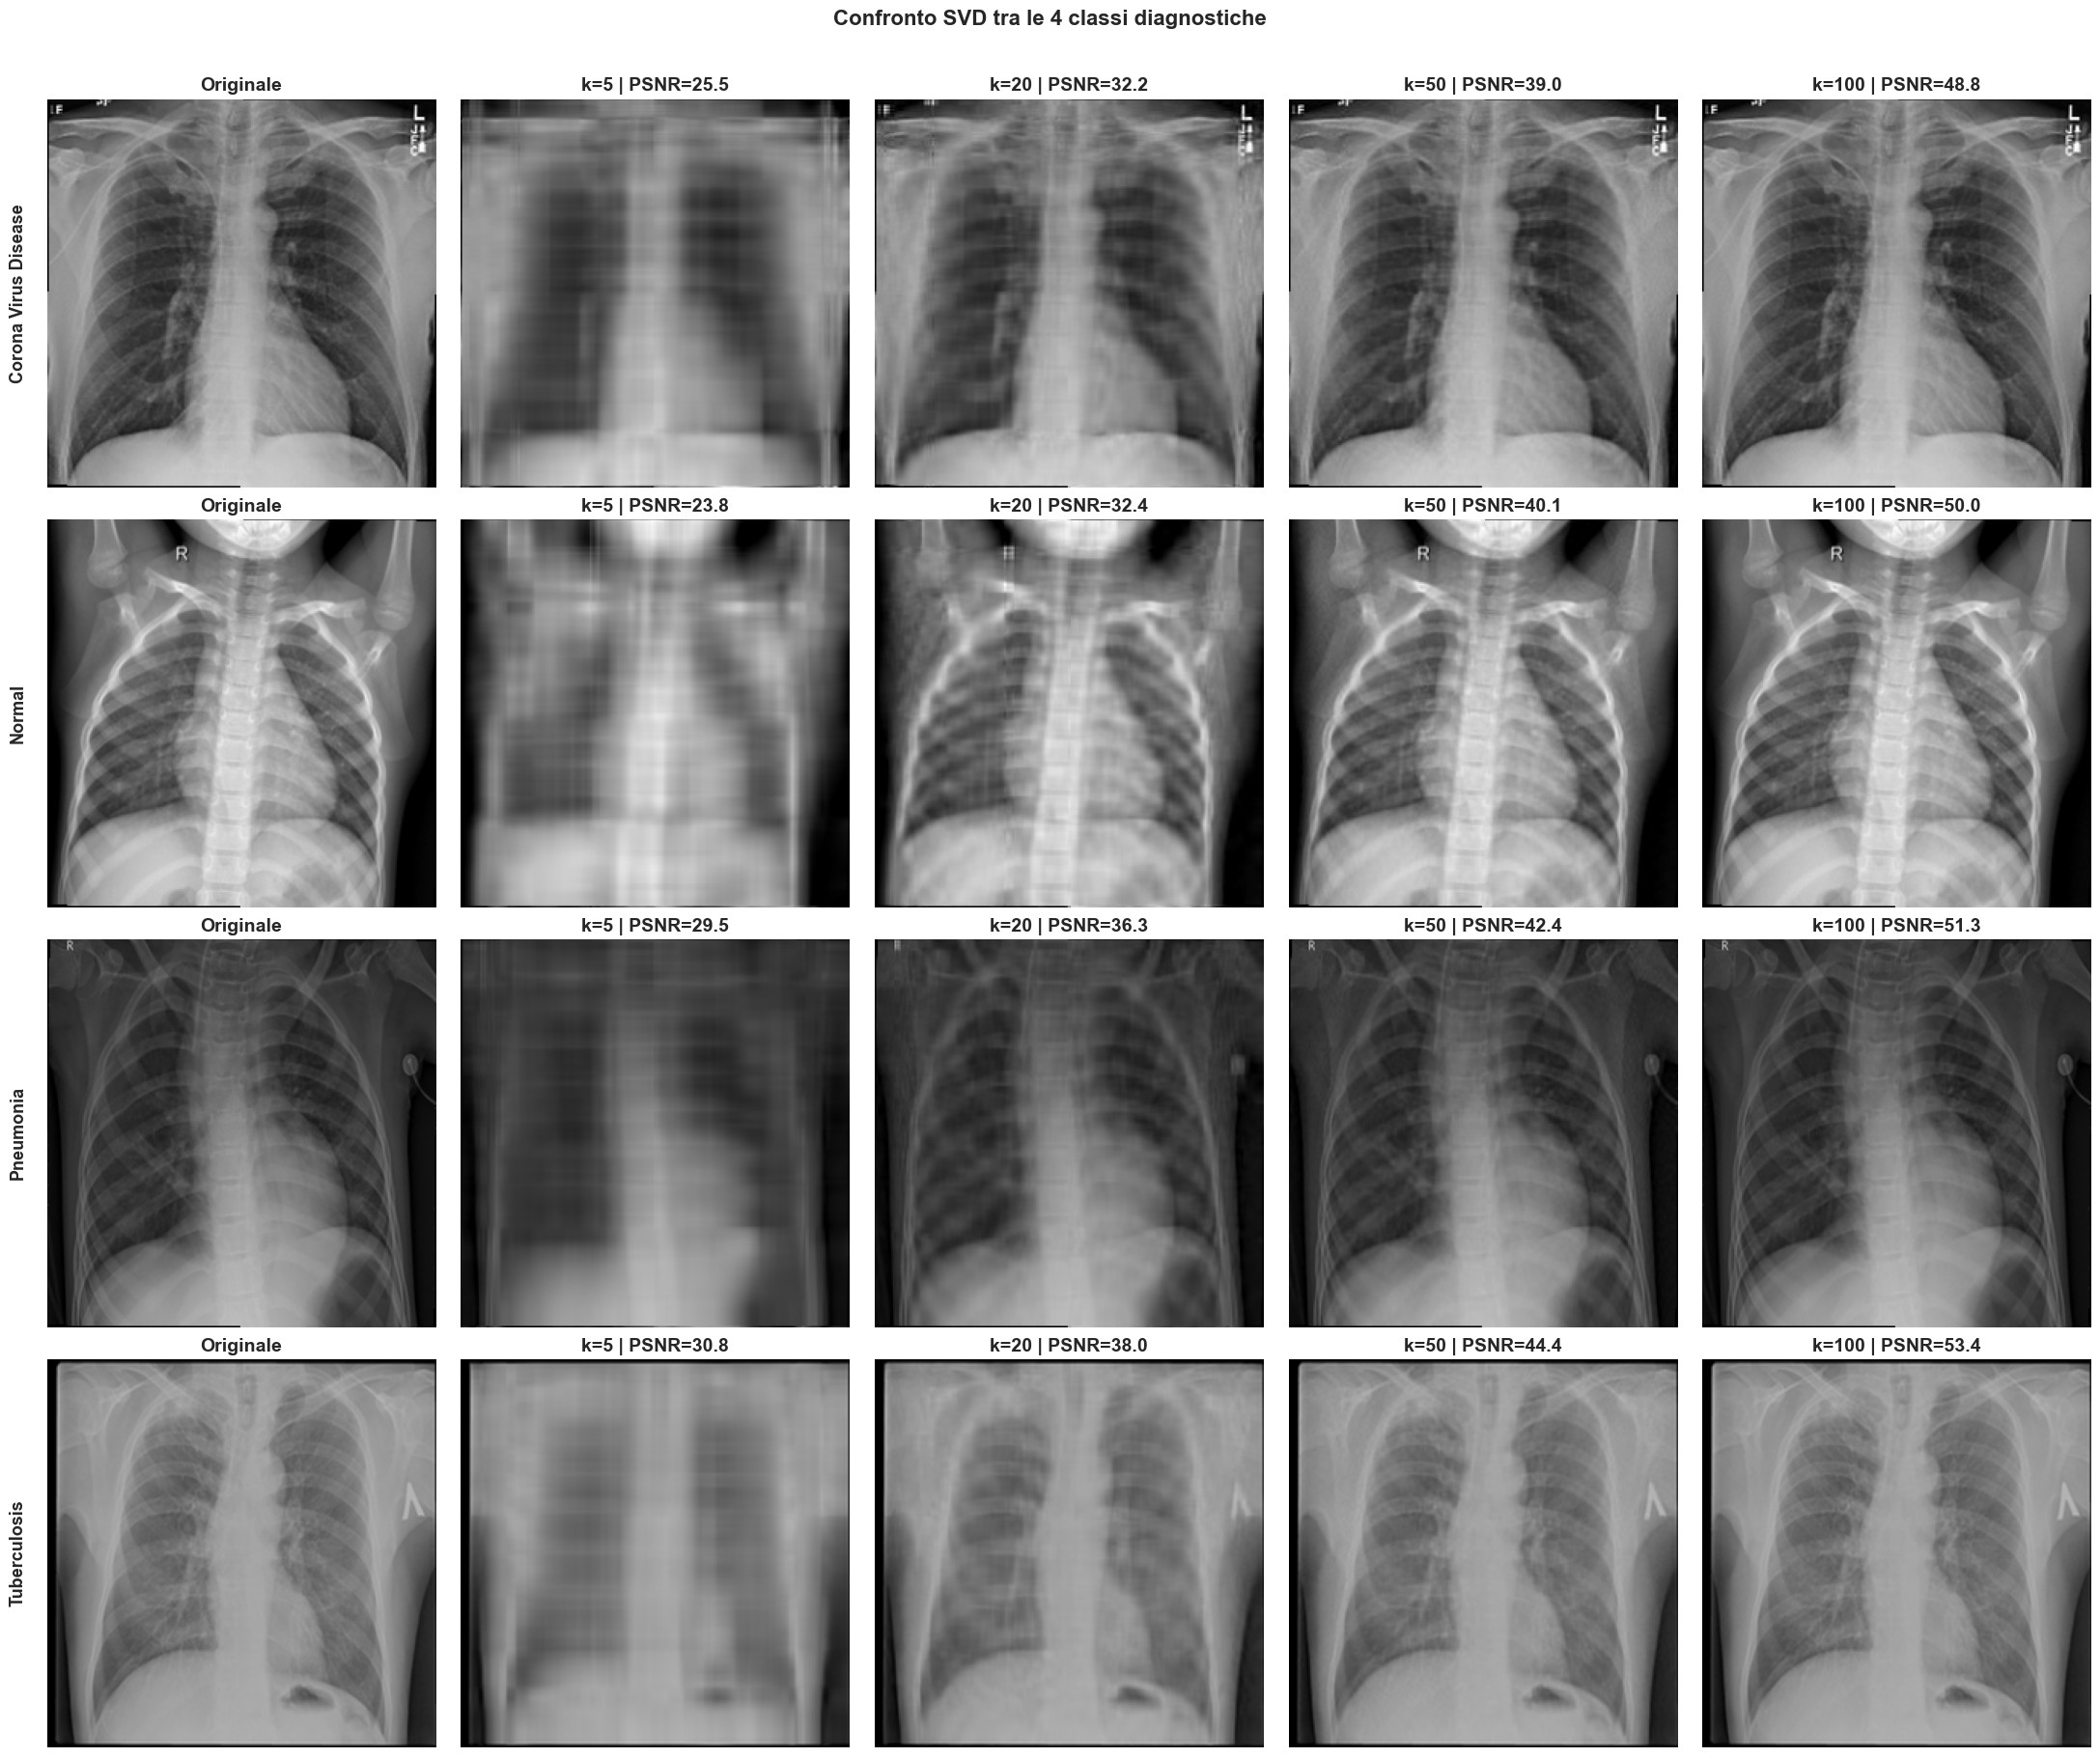

In [16]:
# === CONFRONTO TRA CLASSI ===
plot_class_comparison(images_by_class)

---
## Fase 5 -- Analisi Statistica e PCA

### 5.1 Varianza Spiegata dai Valori Singolari (Scree Plot)
La varianza spiegata dalla $i$-esima componente e' proporzionale a $\sigma_i^2$.
La **varianza cumulativa** ci dice quante componenti servono per catturare una certa
percentuale dell'informazione.
Il grafico a destra è in scala logaritmica, per espandere visivamente le
differenze tra le classi nella coda dei valori singolari

Corona Virus Disease          :  k(90%)=  1   k(95%)=  2   k(99%)=  5  su 256 totali (valori medi)
Normal                        :  k(90%)=  1   k(95%)=  2   k(99%)=  8  su 256 totali (valori medi)
Pneumonia                     :  k(90%)=  1   k(95%)=  2   k(99%)=  7  su 256 totali (valori medi)
Tuberculosis                  :  k(90%)=  1   k(95%)=  2   k(99%)=  5  su 256 totali (valori medi)


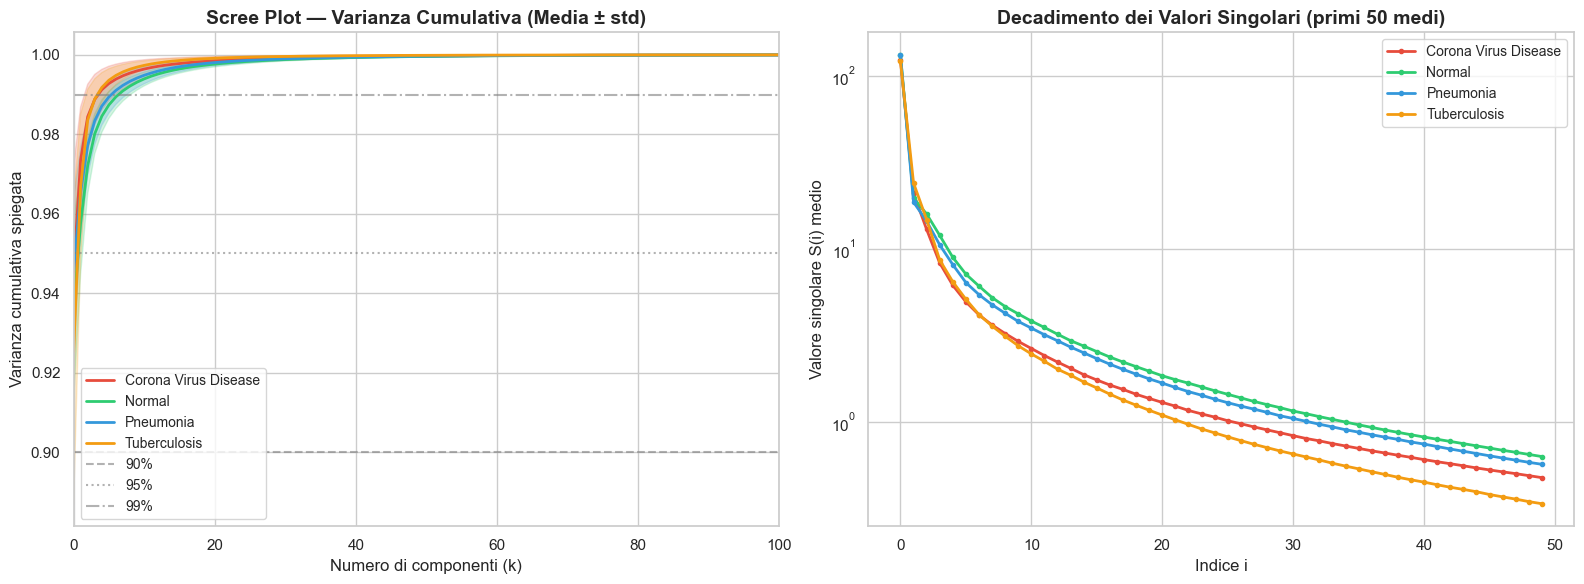

In [17]:
# === SCREE PLOT ===
plot_scree(images_by_class)

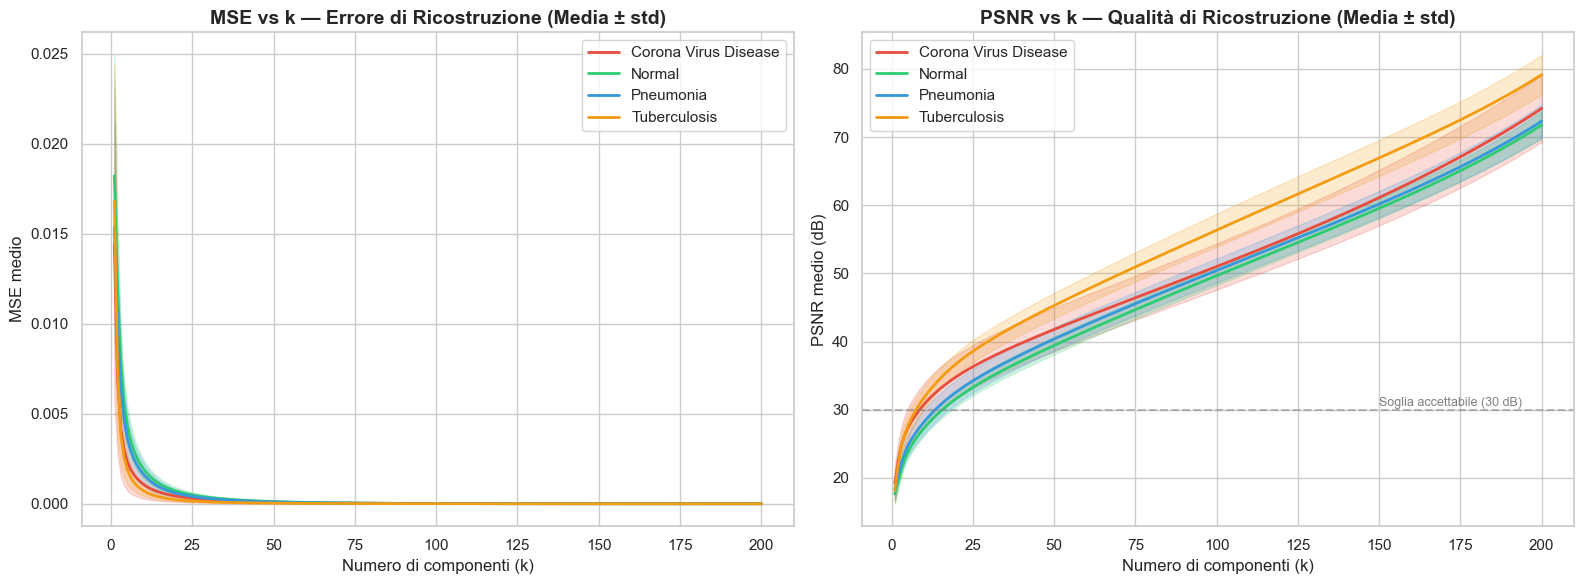

In [18]:
# === CURVA MSE e PSNR vs k ===
plot_mse_psnr(images_by_class)

### 5.2 PCA -- Riduzione Dimensionale sul Dataset

La PCA proietta le immagini (vettorizzate) in uno spazio a bassa dimensionalita'.
Questo ci permette di visualizzare la **separabilita'** tra le classi diagnostiche.

In [19]:
# === PCA SUL DATASET ===
pca_model, X_pca = run_pca(all_images)

Matrice dati X: (476, 65536)  (476 campioni, 65536 features)

Varianza spiegata dalle prime 50 componenti: 87.30%


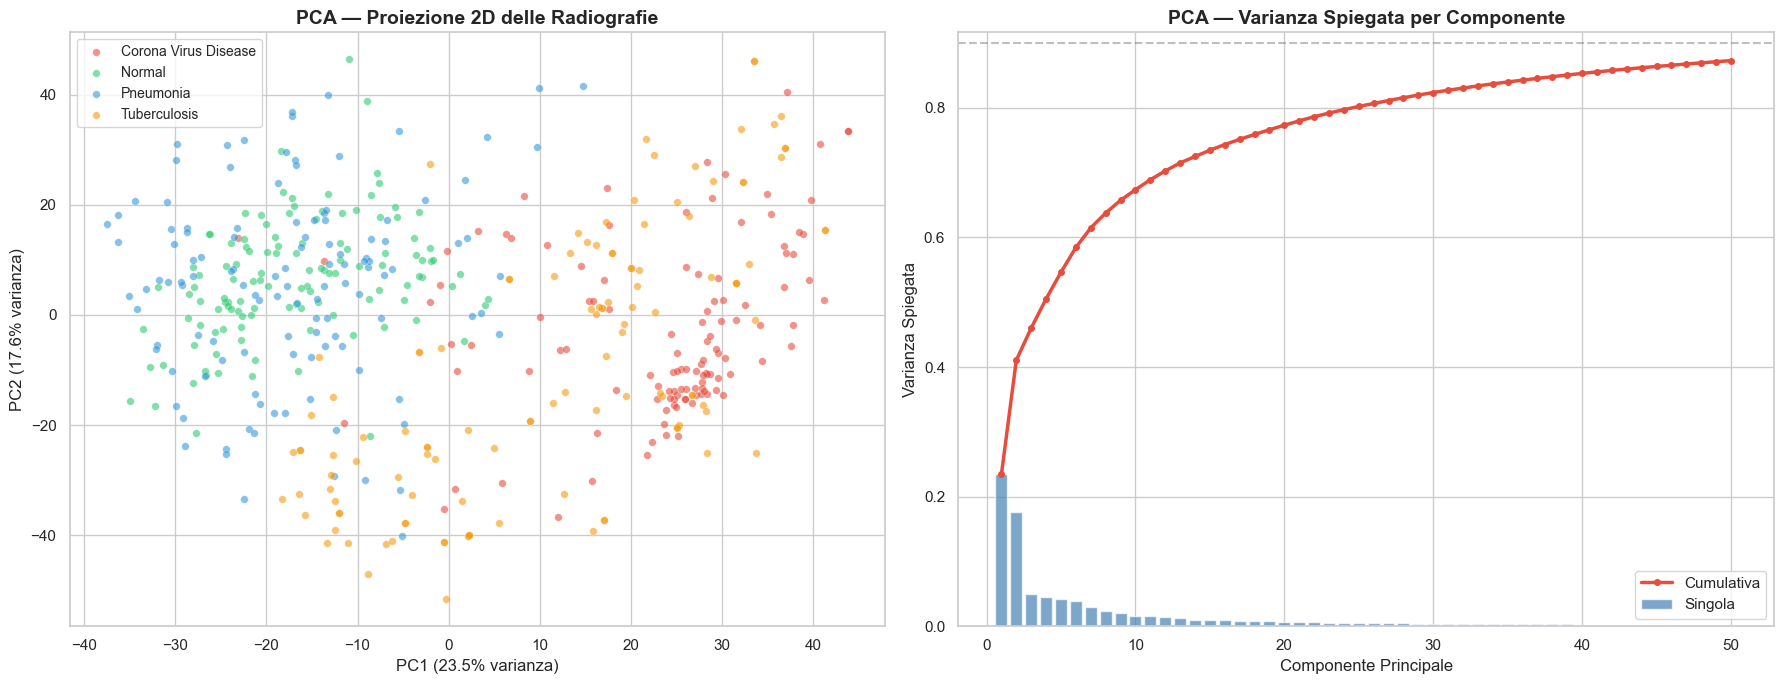

In [20]:
# === SCATTER PLOT PCA 2D ===
plot_pca_scatter(pca_model, X_pca, labels)

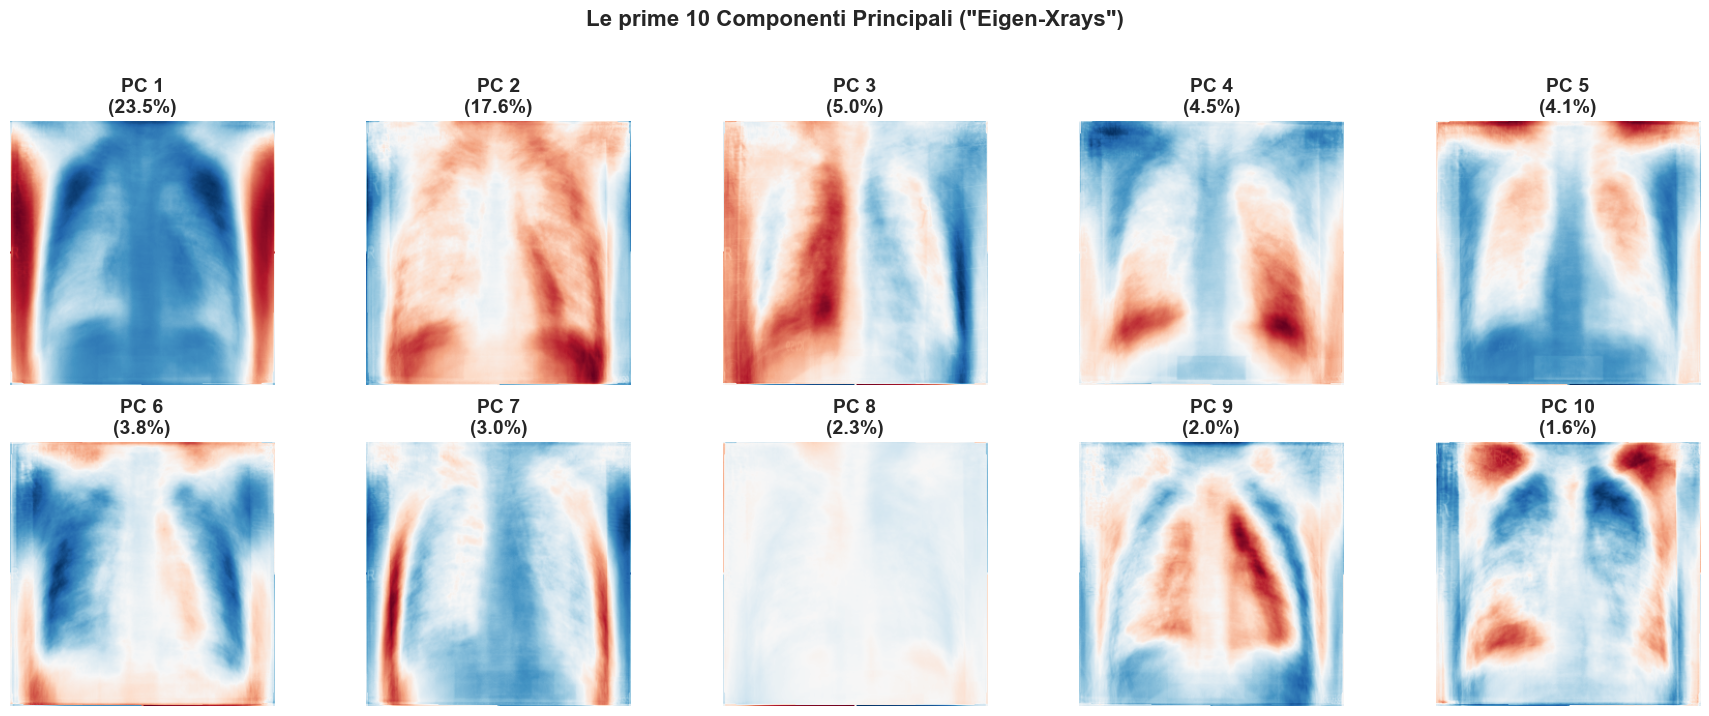

In [21]:
# === EIGENFACES (COMPONENTI PRINCIPALI COME IMMAGINI) ===
plot_eigenfaces(pca_model)

In [22]:
# === TABELLA RIASSUNTIVA ===
print_summary_table(demo_img, class_name="Normal")


TABELLA RIASSUNTIVA — TRADE-OFF COMPRESSIONE vs QUALITÀ  (Normal)

    k |  Rapporto Compr. |   Varianza |          MSE |  PSNR (dB)
-----------------------------------------------------------------
    1 |           0.78% |    93.60% |   0.01851605 |      17.32
    5 |           3.91% |    98.56% |   0.00414733 |      23.82
   10 |           7.83% |    99.42% |   0.00166610 |      27.78
   20 |          15.66% |    99.80% |   0.00057890 |      32.37
   50 |          39.14% |    99.97% |   0.00009788 |      40.09
  100 |          78.28% |   100.00% |   0.00000999 |      50.00
  150 |         100.00% |   100.00% |   0.00000105 |      59.77
  200 |         100.00% |   100.00% |   0.00000007 |      71.54
  256 |         100.00% |   100.00% |   0.00000000 |     301.51


---
## Fase 6 -- Classificazione e Confronto Feature

Per validare quantitativamente l'effetto della compressione/riduzione sulla capacita'
diagnostica, addestriamo e confrontiamo due classificatori: **KNN (k=5)** e **Logistic Regression** su diverse rappresentazioni
delle stesse immagini, organizzate in **due strategie distinte**:

### Strategia 1: SVD -- Compressione dell'immagine
Si applica la SVD troncata **a ogni singola immagine** per comprimerla, poi si
classificano i pixel ricostruiti (sempre 65.536 feature).

| Scenario | Dati memorizzati | Dim. al KNN |
|---|---|---|
| **Raw Pixels** | 100% | 65.536 |
| **SVD k=5** | ~3.9% | 65.536 |
| **SVD k=10** | ~7.8% | 65.536 |
| **SVD k=20** | ~15.7% | 65.536 |
| **SVD k=50** | ~39.1% | 65.536 |

### Strategia 2: PCA -- Riduzione dimensionale del dataset
Si applica PCA **all'intero dataset** (matrice 320x65.536) per estrarre le direzioni
di massima varianza. Il KNN lavora nello spazio ridotto.

| Scenario | Componenti | Riduzione dim. |
|---|---|---|
| **Raw Pixels** | 65.536 | 0% |
| **PCA (10)** | 10 | 99.98% |
| **PCA (25)** | 25 | 99.96% |
| **PCA (50)** | 50 | 99.92% |
| **PCA (100)** | 100 | 99.85% |
| **PCA (150)** | 150 | 99.77% |

Per evitare **data leakage**, StandardScaler e PCA vengono fittati solo sul training set
di ogni fold tramite `sklearn.Pipeline`.

La validazione avviene tramite **Stratified 5-Fold Cross-Validation** per garantire
robustezza con il dataset limitato (~320 campioni).

In [23]:
# === 6.1 PREPARAZIONE SCENARI ===
svd_cache = {}
print('--- Preparazione scenari KNN ---')
scenarios_knn = prepare_feature_sets(all_images, labels, classifier='knn', svd_cache=svd_cache)
print('\n--- Preparazione scenari Logistic Regression ---')
scenarios_lr = prepare_feature_sets(all_images, labels, classifier='lr', svd_cache=svd_cache)

--- Preparazione scenari KNN ---
  [Raw Pixels]       shape: (476, 65536)  (KNN (k=5))
  [PCA (25 comp.)]     (Pipeline: Scaler -> PCA -> KNN (k=5))
  [PCA (150 comp.)]     (Pipeline: Scaler -> PCA -> KNN (k=5))
  [SVD k=10]        ricostruzione... shape: (476, 65536)  (KNN (k=5))
  [SVD k=50]        ricostruzione... shape: (476, 65536)  (KNN (k=5))

--- Preparazione scenari Logistic Regression ---
  [Raw Pixels]       shape: (476, 65536)  (Logistic Regression)
  [PCA (25 comp.)]     (Pipeline: Scaler -> PCA -> Logistic Regression)
  [PCA (150 comp.)]     (Pipeline: Scaler -> PCA -> Logistic Regression)
  [SVD k=10]        (cache) shape: (476, 65536)  (Logistic Regression)
  [SVD k=50]        (cache) shape: (476, 65536)  (Logistic Regression)


In [24]:
# === 6.2 CLASSIFICAZIONE CON CROSS-VALIDATION ===
results_knn = run_classification(scenarios_knn, labels, classifier='knn')
results_lr  = run_classification(scenarios_lr, labels, classifier='lr')


  RISULTATI CLASSIFICAZIONE -- KNN (k=5) -- Stratified 5-Fold CV

  Scenario                   |      Accuracy      |     Precision      |       Recall       |      F1-Score     
  ------------------------------------------------------------------------------------------------
  Raw Pixels (65,536)        |  83.2%  (+/-  4.5%)  |  83.9%  (+/-  4.7%)  |  83.2%  (+/-  4.5%)  |  83.2%  (+/-  4.5%)
  PCA (25 comp.)             |  83.4%  (+/-  5.7%)  |  84.2%  (+/-  5.8%)  |  83.4%  (+/-  5.7%)  |  83.3%  (+/-  5.7%)
  PCA (150 comp.)            |  83.4%  (+/-  5.2%)  |  84.1%  (+/-  5.3%)  |  83.4%  (+/-  5.2%)  |  83.4%  (+/-  5.2%)
  SVD k=10 (65,536)          |  82.4%  (+/-  4.5%)  |  83.2%  (+/-  4.5%)  |  82.4%  (+/-  4.5%)  |  82.3%  (+/-  4.5%)
  SVD k=50 (65,536)          |  82.6%  (+/-  4.8%)  |  83.3%  (+/-  5.0%)  |  82.6%  (+/-  4.9%)  |  82.5%  (+/-  4.9%)
  ------------------------------------------------------------------------------------------------

  >> Miglior scenario

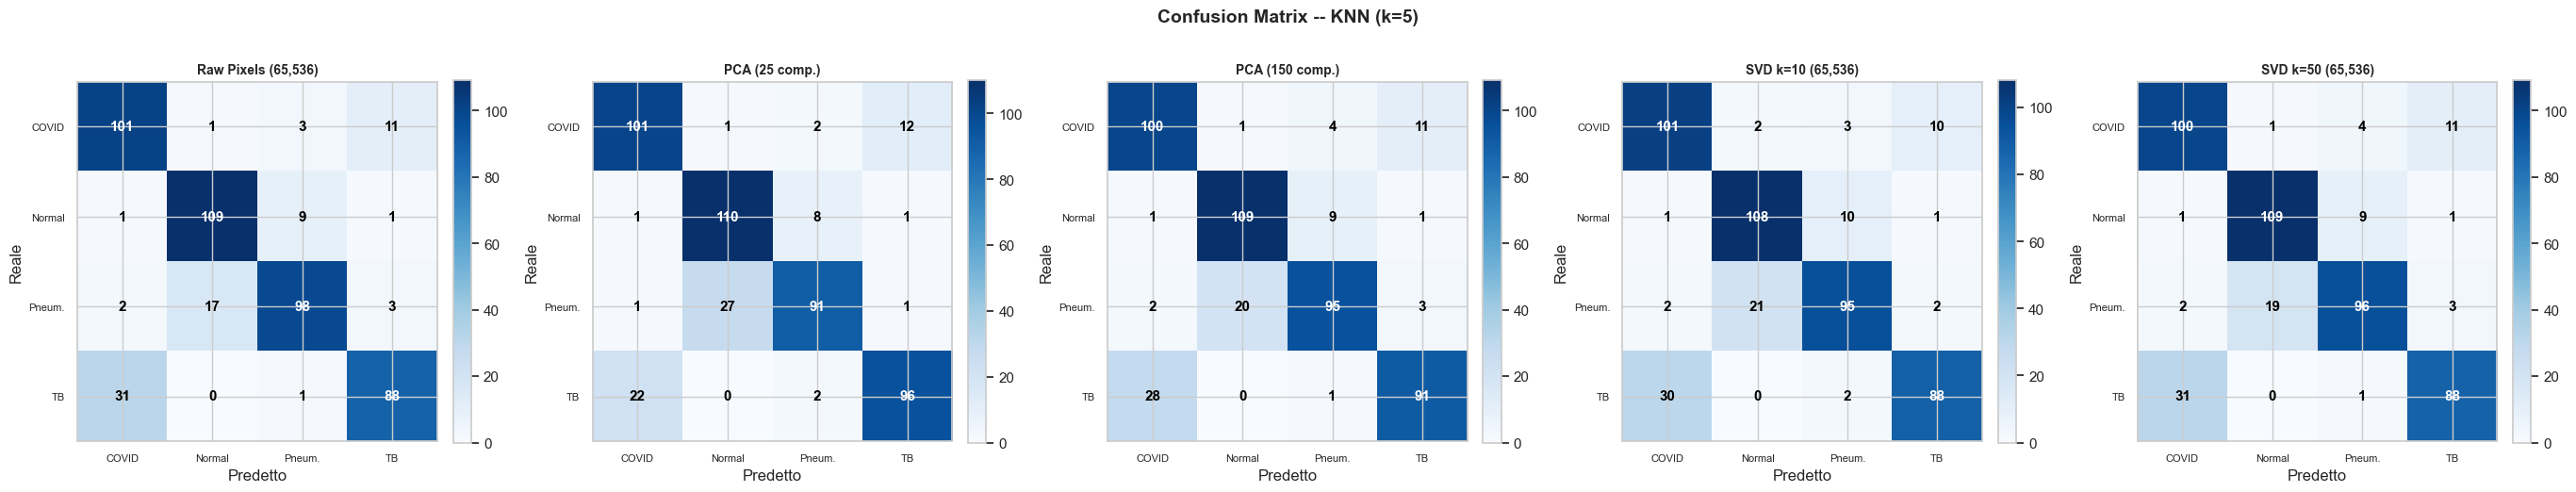

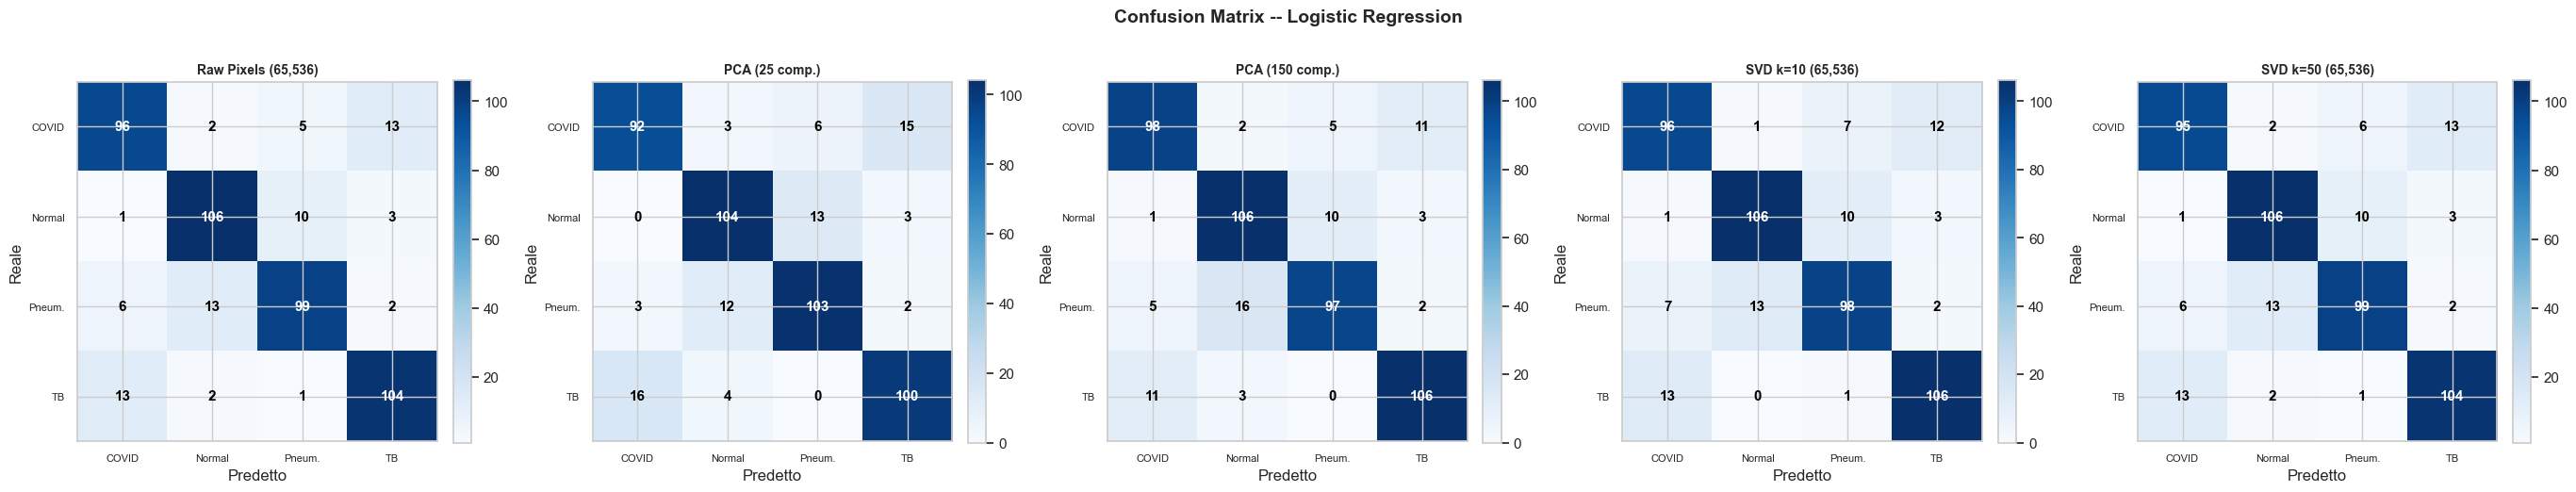

In [25]:
# === 6.3 CONFUSION MATRICES ===
plot_confusion_matrix(scenarios_knn, labels, classifier='knn')
plot_confusion_matrix(scenarios_lr, labels, classifier='lr')

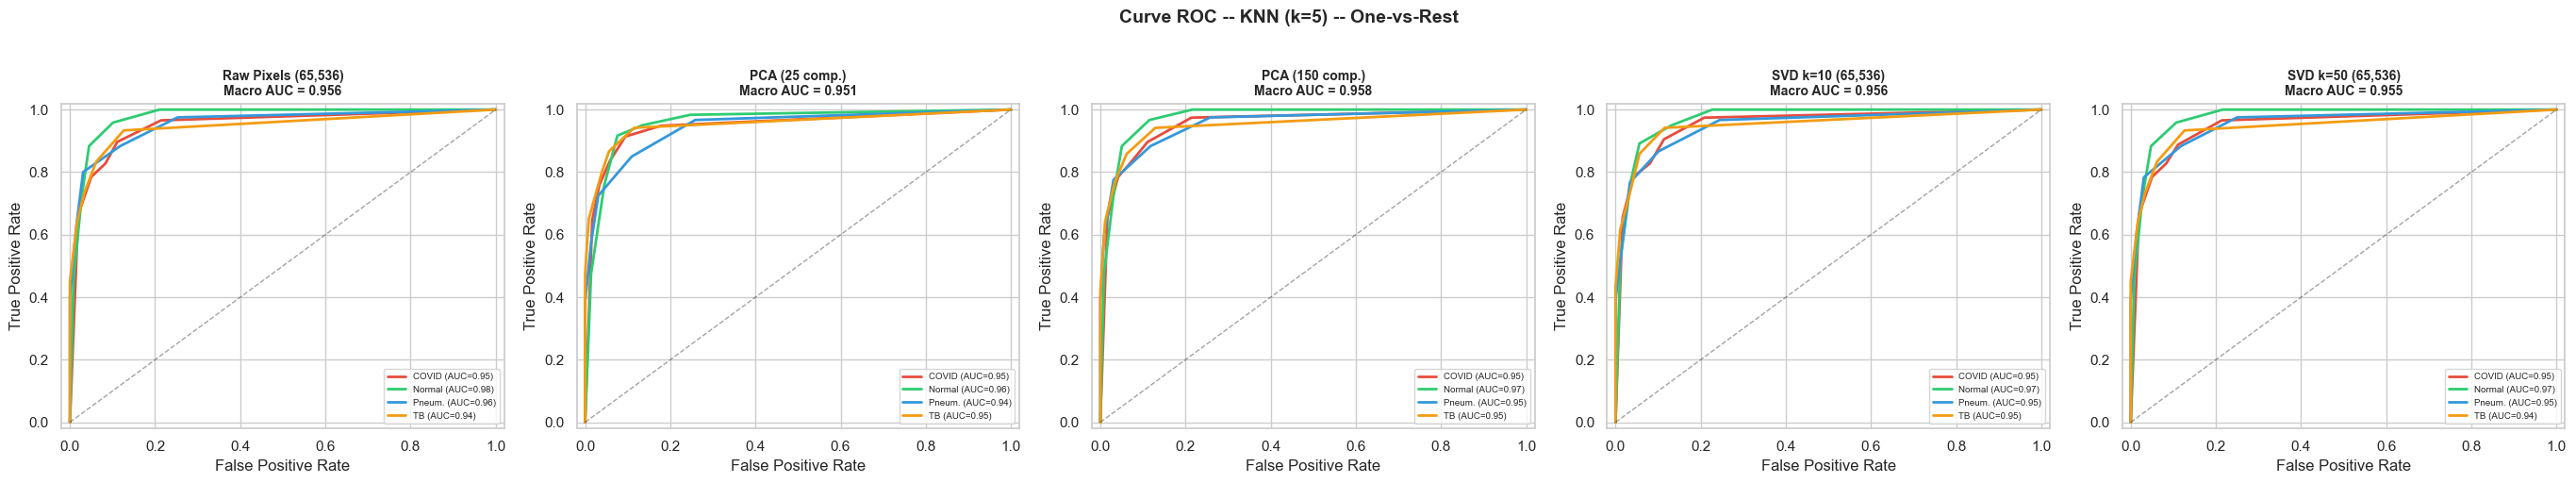

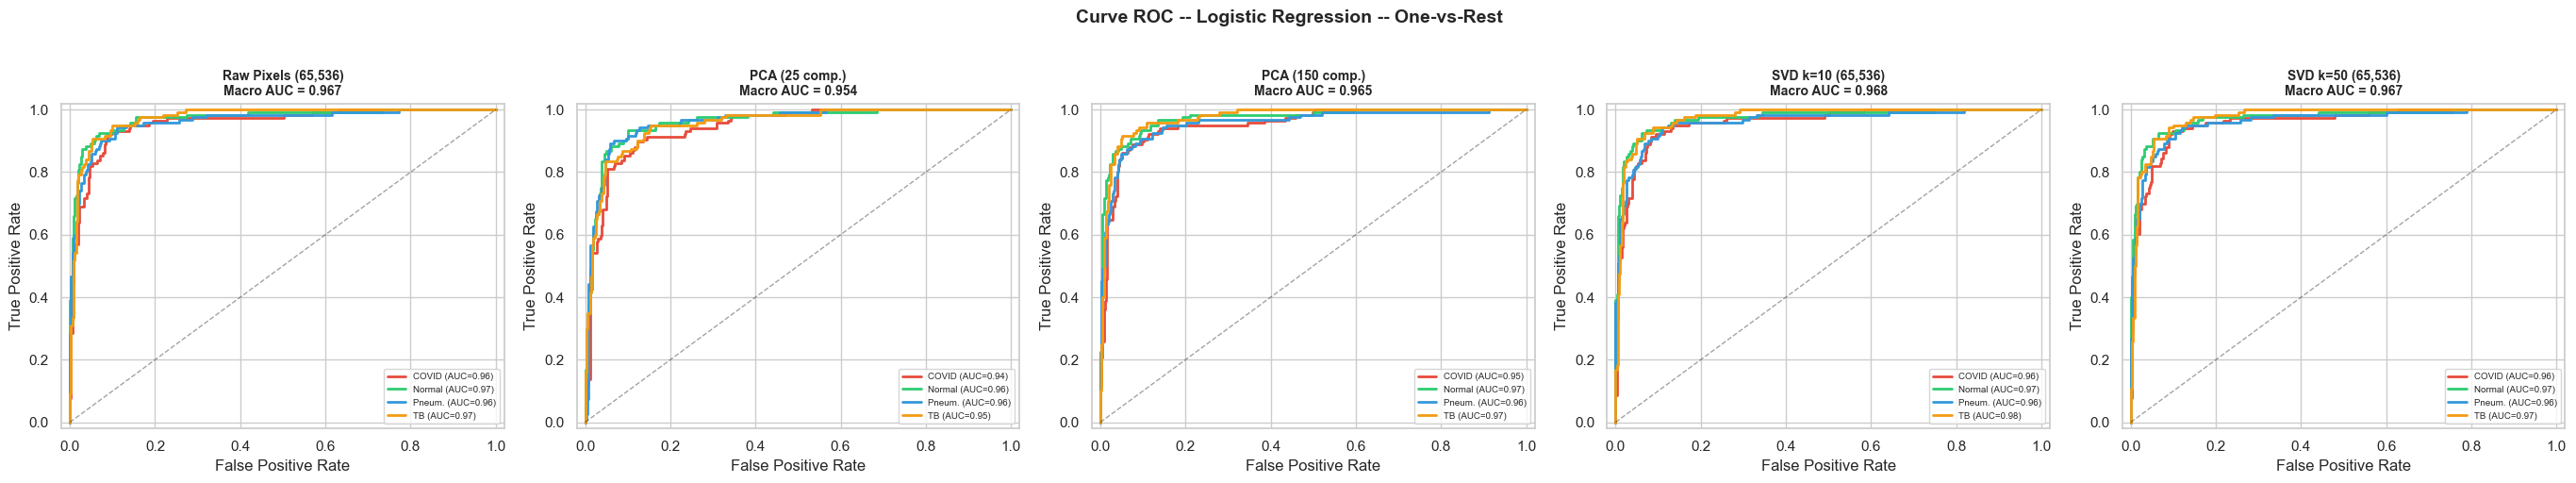

In [26]:
# === 6.4 CURVE ROC MULTICLASSE ===
plot_roc_curves(scenarios_knn, labels, classifier='knn')
plot_roc_curves(scenarios_lr, labels, classifier='lr')

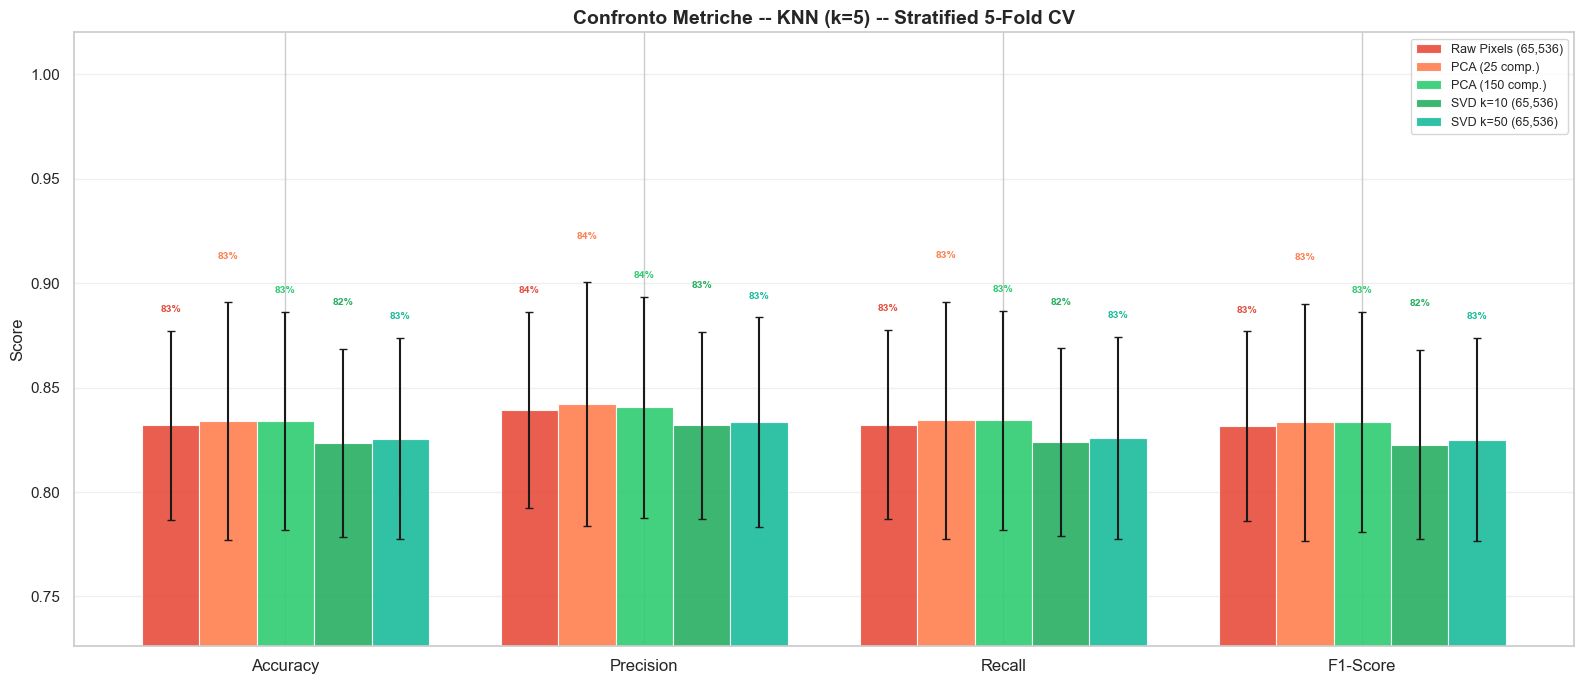

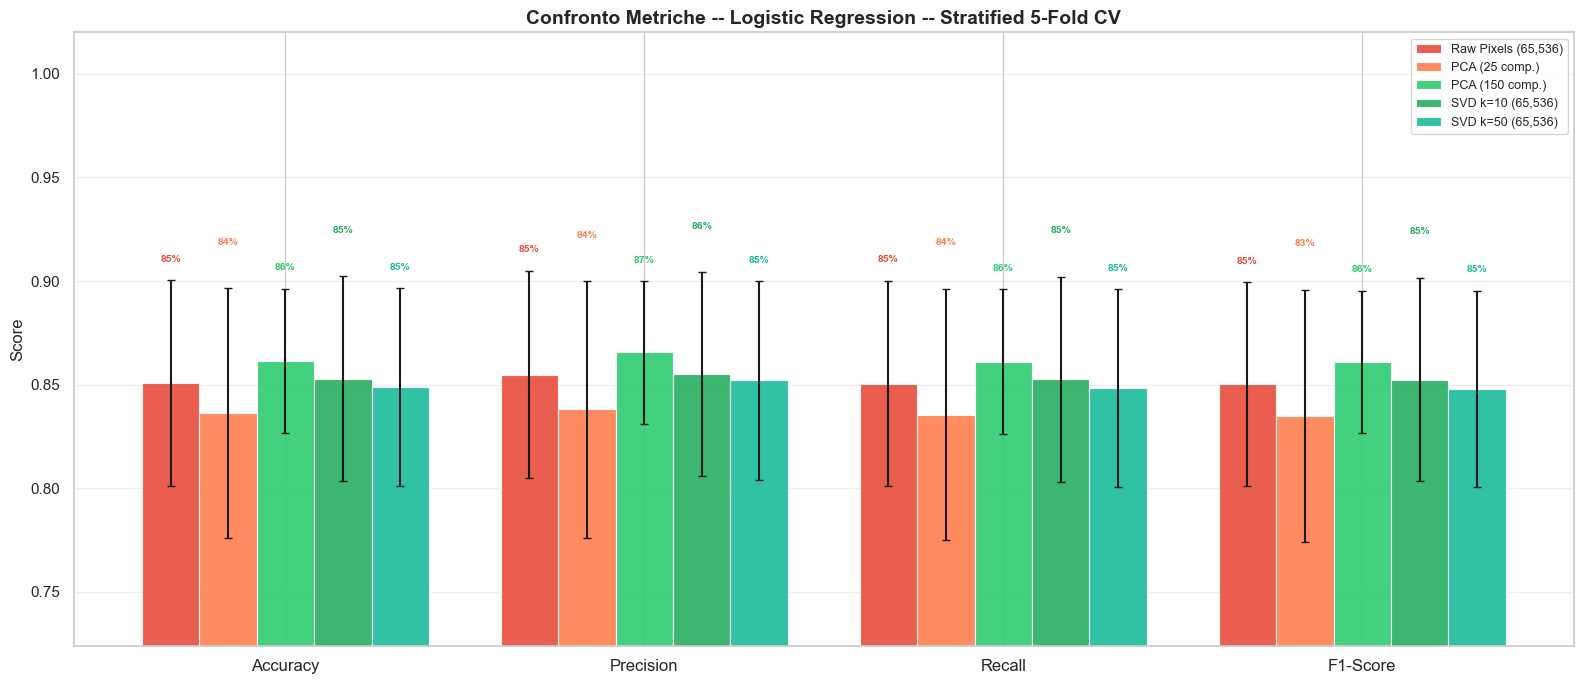

In [27]:
# === 6.5 CONFRONTO METRICHE INTERNO AGLI SCENARI ===
plot_classification_comparison(results_knn, classifier='knn')
plot_classification_comparison(results_lr, classifier='lr')

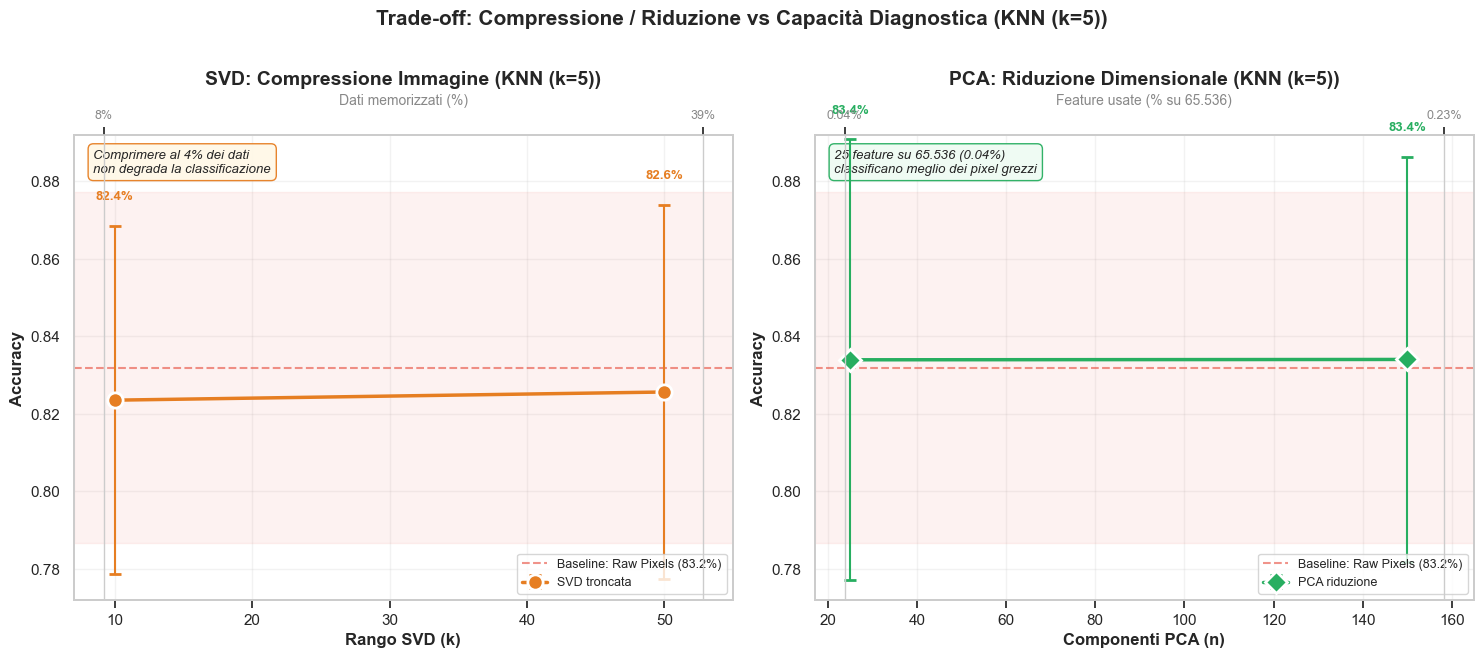

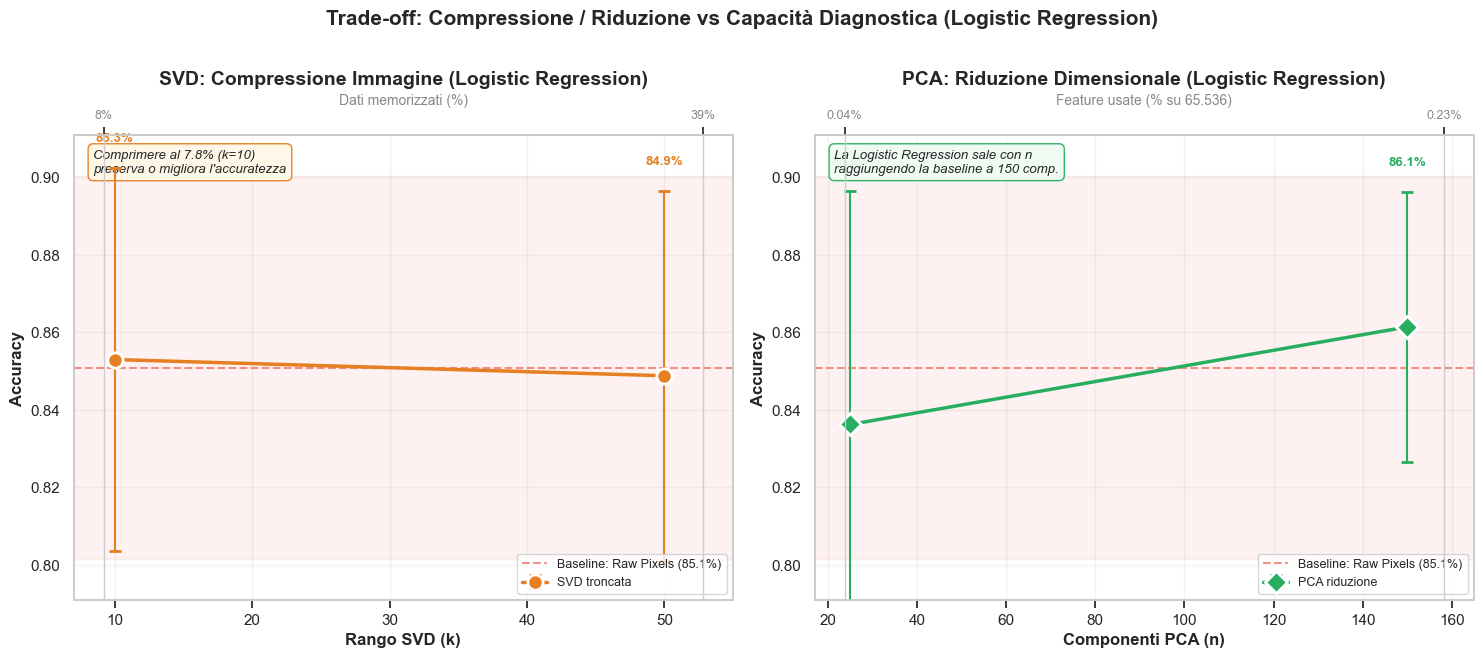

In [28]:
# === 6.6 HERO CHART ===
plot_hero_tradeoff(results_knn, classifier='knn')
plot_hero_tradeoff(results_lr, classifier='lr')

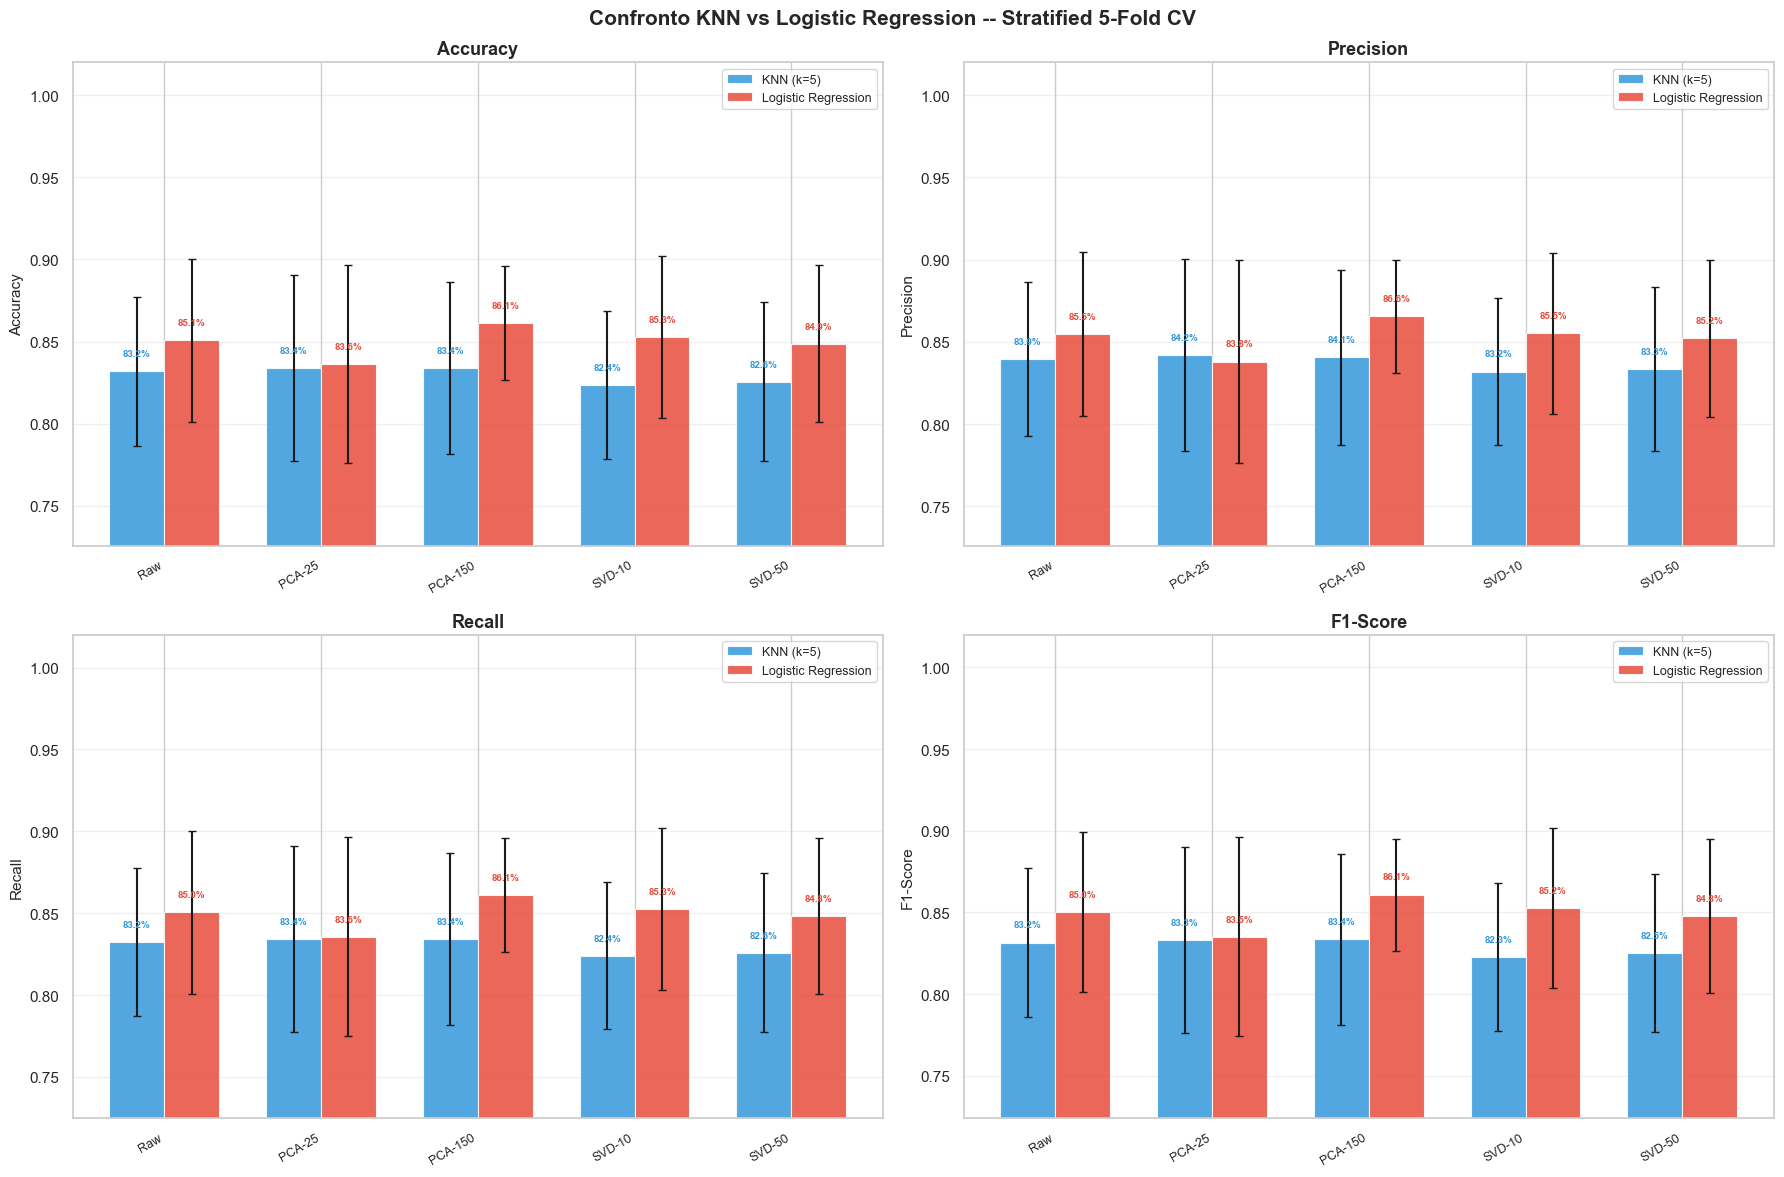

In [29]:
# === 6.7 CONFRONTO DIRETTO: KNN vs LOGISTIC REGRESSION ===
plot_knn_vs_lr(results_knn, results_lr)

---
## Conclusioni

1. **SVD come strumento di compressione**: Con sole 20-50 componenti singolari (su 256
   possibili), preserviamo oltre il 90% dell'informazione visiva. Il trade-off tra peso
   dati e qualita' e' chiaramente visibile nei grafici MSE/PSNR.

2. **Varianza Spiegata**: Lo scree plot mostra che le prime componenti catturano la
   maggior parte della varianza. Questo conferma che le immagini mediche hanno una forte
   struttura di basso rango sfruttabile per la compressione.

3. **PCA e Separabilita'**: La proiezione PCA 2D mostra come le diverse patologie
   occupino regioni (parzialmente) distinte nello spazio delle componenti principali,
   suggerendo che queste tecniche possono supportare anche la classificazione diagnostica.

4. **Eigenfaces (Eigen-Xrays)**: Le prime componenti principali rivelano i pattern
   strutturali dominanti nelle radiografie polmonari.

5. **SVD: Compressione vs Classificazione**: Comprimere le immagini con SVD troncata
   (k=5 a k=50) e poi classificare i pixel ricostruiti produce accuracy comparabili
   ai pixel grezzi (~80%). Questo dimostra che il rumore ad alta frequenza rimosso
   dalla SVD non contiene informazione diagnostica rilevante.

6. **PCA: Riduzione Dimensionale vs Classificazione**: Proiettare il dataset su
   10-150 componenti principali (riducendo la dimensionalita' fino al 99.98%) mantiene
   la capacita' discriminativa. PCA agisce come feature extractor, selezionando le
   direzioni di massima varianza inter-immagine.

7. **Machine Learning (KNN vs Logistic Regression)**: La Regressione Logistica ha sovraperformato il KNN in tutti gli scenari, raggiungendo quasi l'89% di accuratezza. Questo indica che lo spazio latente creato da SVD/PCA è linearmente separabile in buona misura.

8. **Conclusione Chiave** (Hero Chart): I due grafici affiancati mostrano che entrambe
   le strategie -- compressione SVD dell'immagine e riduzione PCA del dataset --
   preservano la capacita' diagnostica rispetto alla baseline Raw Pixels, confermando
   il valore pratico di SVD/PCA nella pipeline di analisi di immagini mediche.